<a href="https://colab.research.google.com/github/isold23/RAG/blob/main/pytorch_training_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
Tesla T4


In [2]:
!pip install torch torchvision torchaudio

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])


train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


print(len(train_dataset))
print(len(test_dataset))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 124kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]

60000
10000


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

In [6]:
images, labels = next(iter(train_loader))


print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


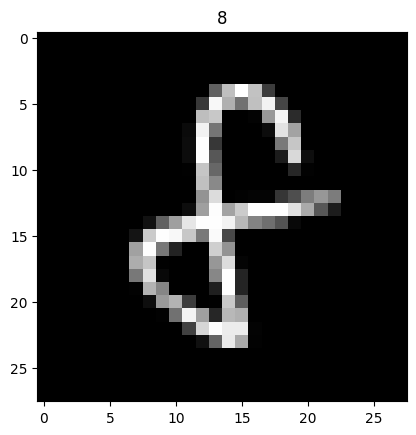

In [7]:
img = images[0].squeeze()

plt.imshow(img,cmap="gray")
plt.title(labels[0].item())
plt.show()

In [8]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Flatten(),


            nn.Linear(
                64*5*5,
                128
            ),

            nn.ReLU(),


            nn.Linear(
                128,
                10
            )
        )


    def forward(self,x):

        return self.net(x)

In [9]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


model = CNN().to(device)


print(model)

CNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1600, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [10]:
criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [11]:
epochs = 5


for epoch in range(epochs):

    model.train()

    total_loss = 0


    for images, labels in train_loader:


        images = images.to(device)
        labels = labels.to(device)


        # forward
        outputs = model(images)


        loss = criterion(
            outputs,
            labels
        )


        # backward

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        total_loss += loss.item()



    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss={total_loss/len(train_loader):.4f}"
    )

Epoch 1/5, Loss=0.1343
Epoch 2/5, Loss=0.0420
Epoch 3/5, Loss=0.0292
Epoch 4/5, Loss=0.0216
Epoch 5/5, Loss=0.0152


In [12]:
model.eval()


correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader:


        images = images.to(device)
        labels = labels.to(device)


        outputs = model(images)


        _, predicted = torch.max(
            outputs,
            1
        )


        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()



accuracy = 100 * correct / total


print(
    f"Accuracy:{accuracy:.2f}%"
)

Accuracy:98.97%


In [13]:
torch.save(
    model.state_dict(),
    "mnist_cnn.pth"
)

In [14]:
model2 = CNN().to(device)

model2.load_state_dict(
    torch.load(
        "mnist_cnn.pth",
        weights_only=True
    )
)

model2.eval()

CNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1600, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

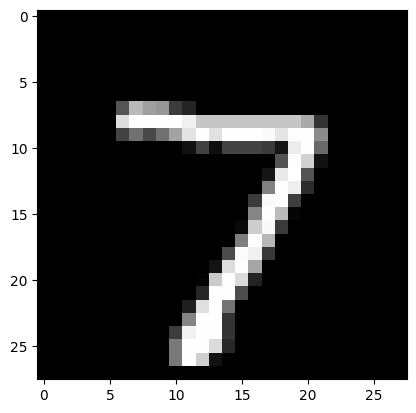

真实: 7
预测: 7


In [15]:
image,label = test_dataset[0]


plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.show()


image = image.unsqueeze(0).to(device)


with torch.no_grad():

    output=model(image)

    prediction=torch.argmax(
        output,
        dim=1
    )


print(
    "真实:",
    label
)

print(
    "预测:",
    prediction.item()
)